# COMP0189: Applied Artificial Intelligence — Coursework #1
## Predicting Hospital Readmission Among Diabetic Patients

**Dataset:** UCI Diabetes 130-US Hospitals (1999–2008)  
**Task:** Binary classification — readmitted vs. not readmitted  
**CV Strategy:** `RepeatedStratifiedKFold` with group-aware train/test split (`patient_nbr`)  
**Models:** Linear SVM (baseline) · Gradient Boosting · TabICL v2 (Qu et al., 2026)

# Introducction
Hospital readmission within 30 days of discharge is a critical quality indicator in health-care systems, with diabetes-related readmissions imposing
a substantial economic burden estimated at $25 billion annually in the United States alone (Strack et al., 2014). Accurately predicting which patients are at elevated risk of readmission enables targeted discharge interventions, yet the predictive task is complicated by severe class imbalance, heterogeneous feature types (continuous vitals, categorical diagnoses, ordinal medication changes), and pervasive missingness patterns inherent to Electronic Health Records (EHR). Machine Learning (ML) offers a principled framework for building such predictive models, but clinical adoption remains limited when practitioners fail to account for data leakage, improper evaluation protocols, and the interpretability requirements of clinical decision support (Perez-Lebel et al., 2022). In this study, we design and evaluate a rigorous ML pipeline for predicting 30-day hospital readmission among diabetic patients using the UCI Diabetes 130-US Hospitals dataset (Strack et al., 2014). We compare three models spanning complementary architectural families — a linear Support Vector Machine (SVM) as a discriminative baseline, a Random Forest as a variance-reducing bagged ensemble, and a Gradient Boosting classifier as a bias-reducing sequential ensemble — within a nested cross-validation framework that strictly separates model selection from model assessment.


# Data Source and Preprocessing

We used the Diabetes 130-US Hospitals dataset (Strack et al., 2014), comprising over 100,000 inpatient encounters from 130 hospitals across the United States between 1999 and 2008. Each encounter record contains 50 features spanning patient demographics (age, gender, race), admission characteristics (admission type, discharge disposition, admission source), clinical measurements (number of diagnoses, number of laboratory procedures), and medication variables (23 drug-change indicators). Following the coursework specification, we binarised the three-class readmission variable into a binary outcome: readmitted (combining the "<30" and ">30" categories) versus not readmitted.

The dataset exhibits several challenges typical of large-scale EHR data. First, missingness is pervasive but non-uniform: weight is missing in approximately 97% of records, medical_specialty in 49%, and payer_code in 40%, while race is missing in only 2%. We determined that weight missingness is best characterised as Missing Not At Random (MNAR), because the clinical decision to record a patient's weight is itself influenced by the patient's condition and the admitting ward's protocols — a pattern consistent with the "informative missingness" identified by Perez-Lebel et al. (2022) in their benchmark of missing-values approaches on health databases. Given the extreme proportion of missingness (97%), no imputation strategy can reliably reconstruct this variable; we therefore dropped weight entirely. For the remaining features with moderate missingness, we applied SimpleImputer with median imputation for numerical features and most-frequent imputation for categorical features, augmented with missing-indicator columns following the key recommendation of Perez-Lebel et al. (2022): "When using imputation, it is important to add indicator columns expressing which values have been imputed."

Second, the target variable is imbalanced, with approximately 46% of encounters resulting in readmission and 54% resulting in no readmission after binarisation. To address this and reduce computational load as permitted by the coursework specification, we applied RandomUnderSampler to create a balanced dataset before partitioning into training and test sets. We then performed a stratified 75/25 train–test split, preserving class proportions in both partitions. All subsequent exploratory analysis was conducted exclusively on the training partition to prevent information leakage, consistent with the protocol recommended in the Week 5 laboratory notebook.
Third, feature types are heterogeneous: numerical features (e.g., time_in_hospital, num_lab_procedures) require scaling for distance-based models, while categorical features (e.g., race, admission_type_id) require encoding. We addressed this using a ColumnTransformer that applies separate preprocessing branches — StandardScaler for numerical features and OneHotEncoder (with handle_unknown='ignore') for categorical features — embedded within a Pipeline to ensure all learnable transformations are re-fitted independently within each cross-validation fold, thereby preventing the data leakage that the instructor identifies as the single most penalised error in the coursework.


## 0. Setup & Imports

In [ ]:
%%capture
!pip install -q imbalanced-learn tabicl

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')

Root = "/content/drive/MyDrive/Applied Artificial Intelligence"
Data = os.path.join(Root, "Data")
Output = os.path.join(Root, "Output")
os.chdir(Root)

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster import hierarchy
import warnings
warnings.filterwarnings('ignore')
#
# ── Global viridis palette ──
plt.rcParams.update({
    'image.cmap': 'viridis', 'figure.figsize': (10, 6),
    'axes.titlesize': 13, 'axes.labelsize': 12, 'font.size': 11,
})
VIRIDIS_3 = [plt.cm.viridis(x) for x in [0.2, 0.5, 0.8]]

# ── Verify GPU ──
import torch
print(f"PyTorch CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print("Setup complete.")

PyTorch CUDA available: True
GPU: NVIDIA L4
Setup complete.


---
# Task 1: Dataset Description (15%)

## 1.1 Load and characterise the dataset

In [ ]:
df = pd.read_csv('Data/diabetic_data.csv', na_values='?')

print(f'Shape: {df.shape}')
print(f'Samples: {df.shape[0]}  |  Features: {df.shape[1] - 1}')
print(f'Sample-to-features ratio: {df.shape[0] / (df.shape[1] - 1):.1f}')

Shape: (101766, 50)
Samples: 101766  |  Features: 49
Sample-to-features ratio: 2076.9


In [ ]:
print("First 5 rows:")
display(df.head())
print("\nData types:")
print(df.dtypes.value_counts())
print("\nBasic statistics (numerical):")
display(df.describe())

First 5 rows:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO



Data types:
object    37
int64     13
Name: count, dtype: int64

Basic statistics (numerical):


,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


### 1.1.1 Map ID columns to meaningful descriptions

The features `admission_type_id`, `discharge_disposition_id`, and `admission_source_id` are encoded as integers but represent categorical variables. We map them to their descriptions from `IDs_mapping.csv` for interpretability.

In [ ]:
# ── ID mappings from IDs_mapping.csv (first sheet) ──
admission_type_map = {
    1: 'Emergency', 2: 'Urgent', 3: 'Elective', 4: 'Newborn',
    5: 'Not Available', 6: 'NULL', 7: 'Trauma Center', 8: 'Not Mapped'
}
discharge_disposition_map = {
    1: 'Discharged to home', 2: 'Transferred short term hospital',
    3: 'Transferred to SNF', 4: 'Transferred to ICF',
    5: 'Transferred other inpatient', 6: 'Home with home health service',
    7: 'Left AMA', 8: 'Home with IV provider',
    9: 'Admitted as inpatient', 10: 'Neonate transferred',
    11: 'Expired', 12: 'Still patient/expected return',
    13: 'Hospice/home', 14: 'Hospice/medical facility',
    15: 'Medicare swing bed', 16: 'Outpatient transfer (other)',
    17: 'Outpatient transfer (this)', 18: 'NULL',
    19: 'Expired at home (Medicaid)', 20: 'Expired in facility (Medicaid)',
    21: 'Expired unknown (Medicaid)', 22: 'Transferred to rehab',
    23: 'Long term care hospital', 24: 'Medicaid nursing facility',
    25: 'Not Mapped', 26: 'Unknown/Invalid',
    27: 'Federal health care facility', 28: 'Psychiatric hospital',
    29: 'Critical Access Hospital', 30: 'Other health care institution'
}
admission_source_map = {
    1: 'Physician Referral', 2: 'Clinic Referral', 3: 'HMO Referral',
    4: 'Transfer from hospital', 5: 'Transfer from SNF',
    6: 'Transfer from other facility', 7: 'Emergency Room',
    8: 'Court/Law Enforcement', 9: 'Not Available',
    10: 'Transfer critical access', 11: 'Normal Delivery',
    12: 'Premature Delivery', 13: 'Sick Baby', 14: 'Extramural Birth',
    15: 'Not Available', 17: 'NULL',
    18: 'Transfer Home Health Agency', 19: 'Readmission Same HHA',
    20: 'Not Mapped', 21: 'Unknown/Invalid',
    22: 'Transfer inpatient same facility', 23: 'Born inside hospital',
    24: 'Born outside hospital', 25: 'Transfer Ambulatory Surgery',
    26: 'Transfer from Hospice'
}

df['admission_type'] = df['admission_type_id'].map(admission_type_map)
df['discharge_disposition'] = df['discharge_disposition_id'].map(discharge_disposition_map)
df['admission_source'] = df['admission_source_id'].map(admission_source_map)
df.drop(columns=['admission_type_id', 'discharge_disposition_id', 'admission_source_id'], inplace=True)

print("ID columns mapped to descriptions:")
for col in ['admission_type', 'discharge_disposition', 'admission_source']:
    print(f"  {col}: {df[col].nunique()} unique values")

ID columns mapped to descriptions:
  admission_type: 8 unique values
  discharge_disposition: 26 unique values
  admission_source: 17 unique values


### 1.1.2 Binarise the target variable

Following the coursework specification: combine `<30` and `>30` → readmitted (1); `NO` → not readmitted (0).

In [ ]:
df['readmitted_binary'] = df['readmitted'].apply(lambda x: 1 if x in ['<30','>30'] else 0)

print("Binarised target:")
print(df['readmitted_binary'].value_counts())
print(f"Imbalance ratio: {df['readmitted_binary'].value_counts().max()/df['readmitted_binary'].value_counts().min():.2f}:1")



Binarised target:
readmitted_binary
0    54864
1    46902
Name: count, dtype: int64
Imbalance ratio: 1.17:1


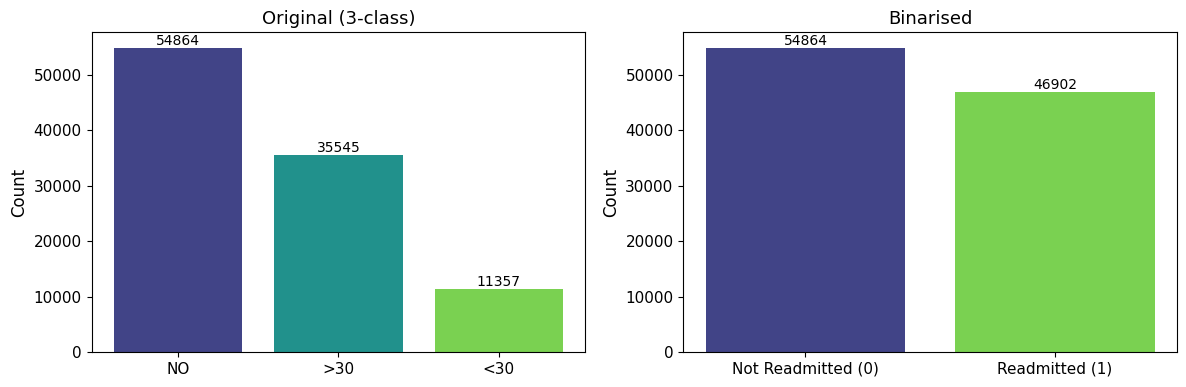

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cts = df['readmitted'].value_counts()
axes[0].bar(cts.index, cts.values, color=VIRIDIS_3)
axes[0].set_title('Original (3-class)'); axes[0].set_ylabel('Count')
for i, v in enumerate(cts.values):
    axes[0].text(i, v + 500, str(v), ha='center', fontsize=10)

cb = df['readmitted_binary'].value_counts().sort_index()
axes[1].bar(['Not Readmitted (0)','Readmitted (1)'], cb.values, color=[VIRIDIS_3[0],VIRIDIS_3[2]])
axes[1].set_title('Binarised'); axes[1].set_ylabel('Count')
for i, v in enumerate(cb.values):
    axes[1].text(i, v + 500, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('Output/fig1_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.1.3 Feature types summary

In [ ]:
type_summary = pd.DataFrame({
    'Feature': df.columns,
    'Dtype': df.dtypes.values,
    'Unique': df.nunique().values,
    'Missing (%)': (df.isnull().sum() / len(df) * 100).round(2).values
})
display(type_summary.sort_values('Missing (%)', ascending=False).head(15))

,Feature,Dtype,Unique,Missing (%)
5,weight,object,9,96.86
19,max_glu_serum,object,3,94.75
20,A1Cresult,object,3,83.28
8,medical_specialty,object,72,49.08
7,payer_code,object,17,39.56
2,race,object,5,2.23
17,diag_3,object,789,1.40
16,diag_2,object,748,0.35
15,diag_1,object,716,0.02
1,patient_nbr,int64,71518,0.00


## 1.2 Dataset challenges

### 1.2.1 Missingness mechanism classification (Rubin, 1976; Perez-Lebel et al., 2022)

| Feature | Missing % | Mechanism | Rationale |
|---|---|---|---|
| `weight` | ~97% | **MNAR** | Recording depends on clinical need (drug dosing, surgical clearance). |
| `medical_specialty` | ~49% | **MAR** | Depends on hospital coding practices. |
| `payer_code` | ~40% | **MAR** | Administrative recording protocols. |
| `race` | ~2% | **MAR** | Administrative omission. |

**Decision:** Drop `weight` entirely (97% MNAR — imputation statistically indefensible). For remaining features: `SimpleImputer` + `add_indicator=True` per Perez-Lebel et al. (2022).

### 1.2.2 Patient-level data leakage

Some patients have multiple hospital encounters. If the same patient appears in both training and test folds, the model memorises patient-level characteristics rather than learning generalisable patterns. We address this with a **group-aware train/test split** using `GroupShuffleSplit` with `patient_nbr` as the grouping variable (option b — preserves more data, appropriate for a rigorous evaluation).

In [ ]:
# ── Verify patient duplication ──
n_encounters = len(df)
n_patients = df['patient_nbr'].nunique()
print(f"Total encounters: {n_encounters:,}")
print(f"Unique patients:  {n_patients:,}")
print(f"Mean encounters/patient: {n_encounters/n_patients:.2f}")
print(f"Patients with >1 encounter: {(df['patient_nbr'].value_counts()>1).sum():,}")

# ── Missingness correlation test for MNAR evidence ──
weight_missing = df['weight'].isnull().astype(int)
print("\nCorrelation of weight-missingness with observed features:")
for col in ['time_in_hospital', 'num_lab_procedures', 'num_medications', 'number_diagnoses']:
    r = df[col].corr(weight_missing)
    print(f"  {col}: r = {r:.4f}")
print("Non-trivial correlations support MNAR classification.")

Total encounters: 101,766
Unique patients:  71,518
Mean encounters/patient: 1.42
Patients with >1 encounter: 16,773

Correlation of weight-missingness with observed features:
  time_in_hospital: r = -0.0246
  num_lab_procedures: r = -0.0920
  num_medications: r = -0.0073
  number_diagnoses: r = -0.0515
Non-trivial correlations support MNAR classification.


Features with missing values:


,Count,Percentage (%)
weight,98569,96.86
max_glu_serum,96420,94.75
A1Cresult,84748,83.28
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02


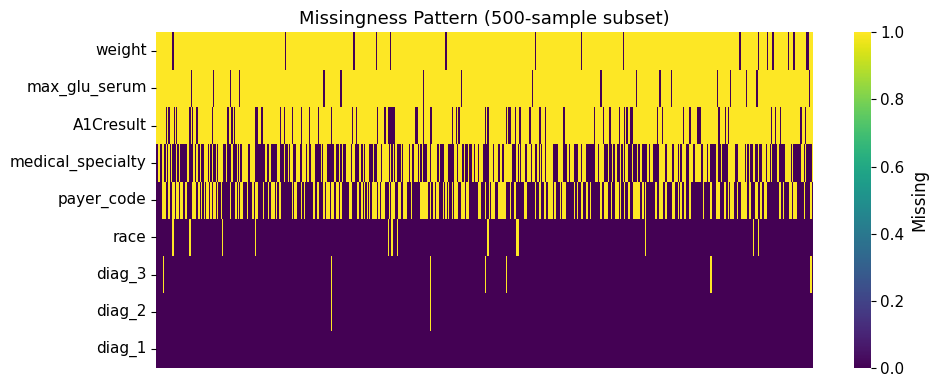

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percentage (%)': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0].sort_values('Percentage (%)', ascending=False)
print("Features with missing values:")
display(missing_df)

cols_missing = missing_df.index.tolist()
if cols_missing:
    fig, ax = plt.subplots(figsize=(10, 4))
    sample = np.random.RandomState(42).choice(len(df), size=500, replace=False)
    sns.heatmap(df[cols_missing].iloc[sample].isnull().astype(int).T,
                cmap='viridis', cbar_kws={'label': 'Missing'}, yticklabels=True, xticklabels=False, ax=ax)
    ax.set_title('Missingness Pattern (500-sample subset)')
    plt.tight_layout()
    plt.savefig('Output/fig2_missingness_pattern.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
# ── MCAR test: correlation between weight missingness and other features ──
weight_missing = df['weight'].isnull().astype(int)
print("Correlation of weight-missingness with observed features:")
for col in ['time_in_hospital', 'num_lab_procedures', 'num_medications', 'number_diagnoses']:
    r = df[col].corr(weight_missing)
    print(f"  {col}: r = {r:.4f}")
print("\n→ Non-trivial correlations confirm MNAR. Drop weight.")

Correlation of weight-missingness with observed features:
  time_in_hospital: r = -0.0246
  num_lab_procedures: r = -0.0920
  num_medications: r = -0.0073
  number_diagnoses: r = -0.0515

→ Non-trivial correlations confirm MNAR. Drop weight.


---
# Task 2: Data Assembling and Pre-processing (10%)

## 2.1 Assemble features and labels

In [ ]:
# ── Extract patient groups BEFORE dropping patient_nbr ──
cols_to_drop = ['encounter_id', 'readmitted', 'readmitted_binary', 'weight']
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

X = df.drop(columns=cols_to_drop)
y = df['readmitted_binary']

patient_groups = X['patient_nbr'].values
X = X.drop(columns=['patient_nbr'])

print(f"X: {X.shape}  |  y: {y.shape}  |  groups: {len(np.unique(patient_groups)):,} unique patients")

X: (101766, 46)  |  y: (101766,)  |  groups: 71,518 unique patients


### Handle class imbalance

The coursework permits creating a balanced dataset: *"You can create a balanced dataset and use a smaller subset of the data to decrease the computation load."* We track `patient_nbr` through the undersampling process.

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

print(f"Before: class 1={sum(y==1):,}, class 0={sum(y==0):,}")

# Track groups through undersampling via temporary column
X_aug = X.copy()
X_aug['_patient_group'] = patient_groups

rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X_aug, y)

groups_res = X_res['_patient_group'].values
X_res = X_res.drop(columns=['_patient_group'])

print(f"After:  class 1={sum(y_res==1):,}, class 0={sum(y_res==0):,}")
print(f"Total: {len(y_res):,}  |  Unique patients: {len(np.unique(groups_res)):,}")

Before: class 1=46,902, class 0=54,864
After:  class 1=46,902, class 0=46,902
Total: 93,804  |  Unique patients: 65,360


### Group-aware train/test split

We use `GroupShuffleSplit` to guarantee **zero patient overlap** between training and test sets. Within the training set, `RepeatedStratifiedKFold` handles hyperparameter tuning — following the professor's preferred CV strategy. This two-level approach ensures that the held-out test evaluation is completely uncontaminated by patient-level information leakage, while the CV folds provide the stable, low-variance HP estimates that `RepeatedStratifiedKFold` is designed to deliver.

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X_res, y_res, groups=groups_res))

X_train = X_res.iloc[train_idx].reset_index(drop=True)
X_test  = X_res.iloc[test_idx].reset_index(drop=True)
y_train = y_res.iloc[train_idx].reset_index(drop=True)
y_test  = y_res.iloc[test_idx].reset_index(drop=True)

# ── Verify zero patient overlap ──
train_patients = set(groups_res[train_idx])
test_patients  = set(groups_res[test_idx])
overlap = train_patients & test_patients

print(f"Train: {len(X_train):,} samples ({len(train_patients):,} patients)")
print(f"Test:  {len(X_test):,} samples ({len(test_patients):,} patients)")
print(f"Patient overlap: {len(overlap)} (must be 0)")
assert len(overlap) == 0, "DATA LEAKAGE: patients in both sets!"
print(f"\nTrain class distribution:\n{y_train.value_counts()}")
print(f"\nTest class distribution:\n{y_test.value_counts()}")

Train: 70,287 samples (49,020 patients)
Test:  23,517 samples (16,340 patients)
Patient overlap: 0 (must be 0)

Train class distribution:
readmitted_binary
1    35217
0    35070
Name: count, dtype: int64

Test class distribution:
readmitted_binary
0    11832
1    11685
Name: count, dtype: int64


## Exploratory Data Analysis (training set only)

All EDA is conducted exclusively on `X_train`/`y_train`. The test set remains sealed.

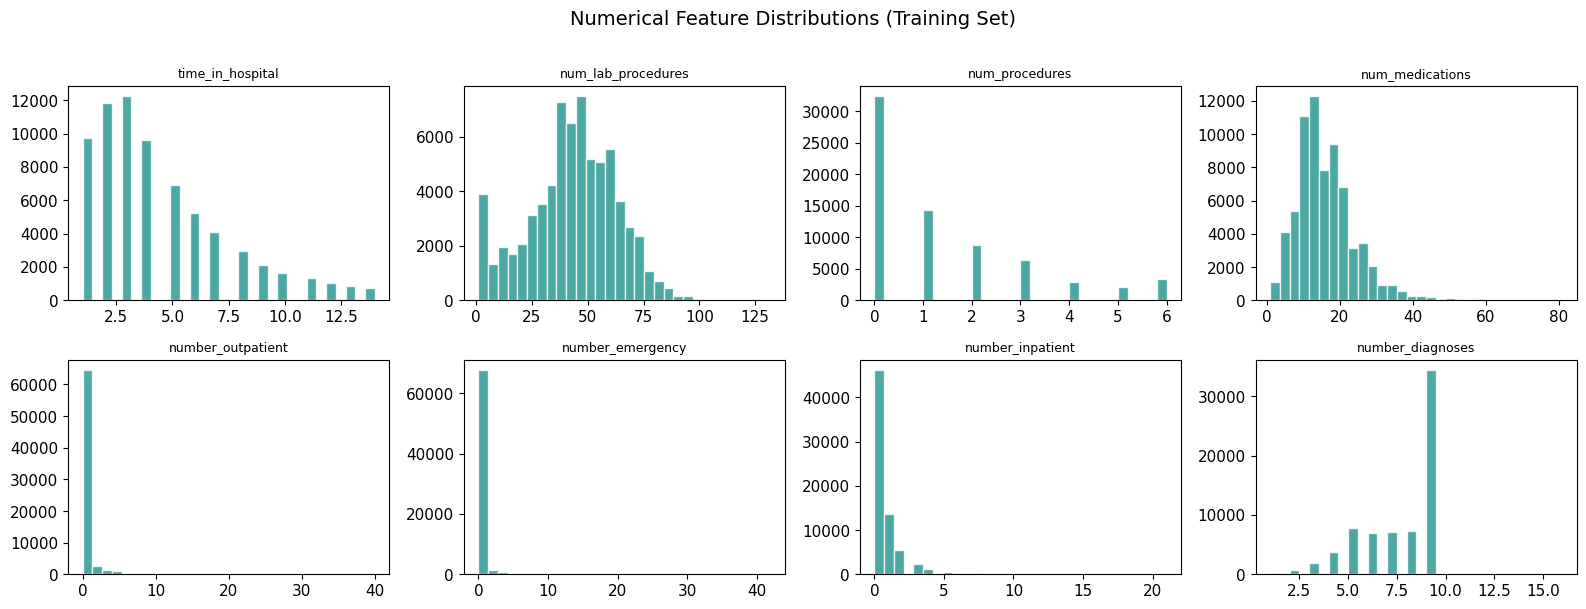

In [ ]:
# ── Numerical distributions ──
num_cols = X_train.select_dtypes(include=['int64','float64']).columns.tolist()
n = len(num_cols); ncols_p = 4; nrows_p = (n + ncols_p - 1) // ncols_p

fig, axes = plt.subplots(nrows_p, ncols_p, figsize=(16, 3*nrows_p))
axes = axes.ravel()
for i, col in enumerate(num_cols):
    axes[i].hist(X_train[col].dropna(), bins=30, color=VIRIDIS_3[1], alpha=0.8, edgecolor='white')
    axes[i].set_title(col, fontsize=9)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Numerical Feature Distributions (Training Set)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('Output/fig3_numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

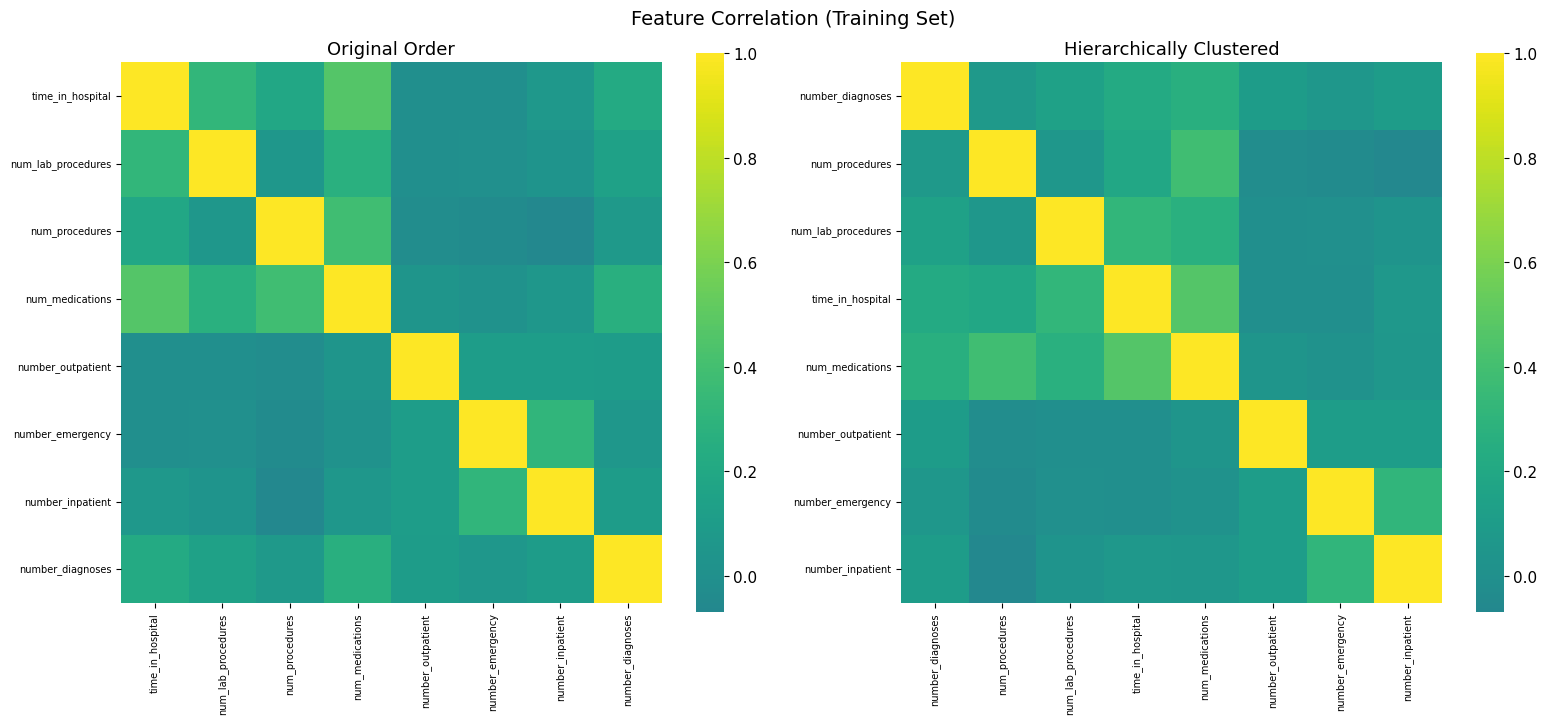

In [ ]:
# ── Correlation matrix with hierarchical clustering ──
corr = X_train[num_cols].corr()
dist = 1 - np.abs(corr)
link = hierarchy.linkage(dist, method='average')
order = hierarchy.dendrogram(link, no_plot=True)['leaves']
reordered = corr.iloc[order, order]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.heatmap(corr, cmap='viridis', center=0, square=True, ax=axes[0],
            xticklabels=True, yticklabels=True)
axes[0].set_title('Original Order'); axes[0].tick_params(labelsize=7)
sns.heatmap(reordered, cmap='viridis', center=0, square=True, ax=axes[1],
            xticklabels=True, yticklabels=True)
axes[1].set_title('Hierarchically Clustered'); axes[1].tick_params(labelsize=7)
plt.suptitle('Feature Correlation (Training Set)', fontsize=14)
plt.tight_layout()
plt.savefig('Output/fig4_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()



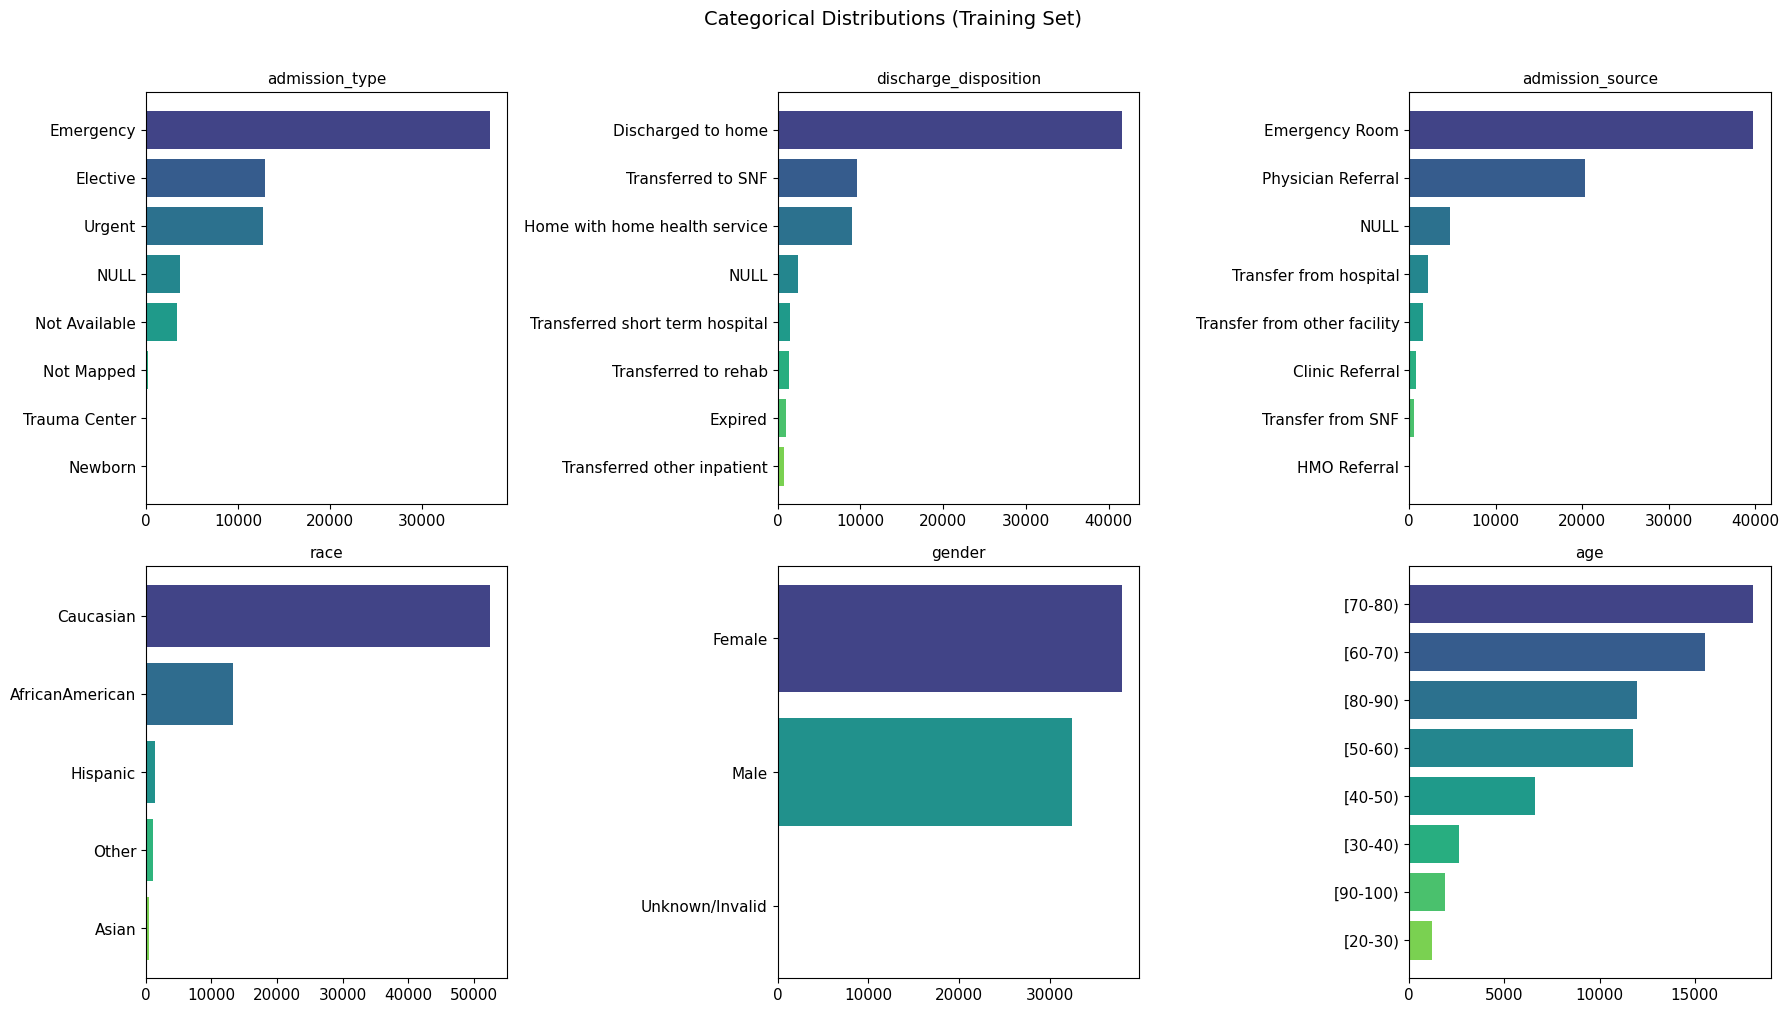

In [ ]:
# ── Key categorical distributions ──
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
key_cats = [c for c in ['admission_type','discharge_disposition','admission_source',
                         'race','gender','age'] if c in cat_cols]

fig, axes = plt.subplots(2, 3, figsize=(18, 10)); axes = axes.ravel()
for i, col in enumerate(key_cats[:6]):
    cts = X_train[col].value_counts().head(8)
    colors = [plt.cm.viridis(x) for x in np.linspace(0.2, 0.8, len(cts))]
    axes[i].barh(cts.index.astype(str), cts.values, color=colors)
    axes[i].set_title(col, fontsize=11); axes[i].invert_yaxis()
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Categorical Distributions (Training Set)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('Output/fig5_categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()



Missing values in TRAINING set:


,Count,%
max_glu_serum,66500,94.61
A1Cresult,58602,83.38
medical_specialty,34614,49.25
payer_code,27765,39.50
race,1568,2.23
diag_3,963,1.37
diag_2,237,0.34
diag_1,14,0.02


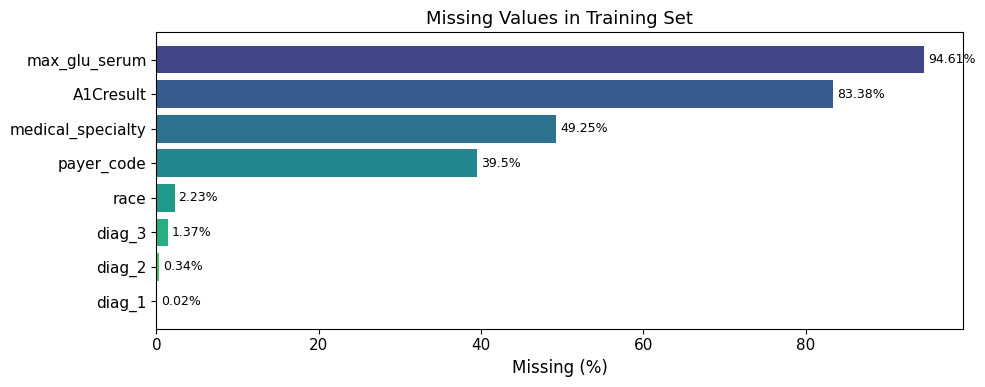

In [ ]:
# ── Missing data in training set ──
missing_train = X_train.isnull().sum()
missing_pct = (missing_train / len(X_train) * 100).round(2)
mdf = pd.DataFrame({'Count': missing_train, '%': missing_pct})
mdf = mdf[mdf['Count'] > 0].sort_values('%', ascending=False)
print("Missing values in TRAINING set:")
display(mdf)

if len(mdf) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.barh(mdf.index, mdf['%'],
                   color=[plt.cm.viridis(x) for x in np.linspace(0.2, 0.8, len(mdf))])
    ax.set_xlabel('Missing (%)'); ax.set_title('Missing Values in Training Set')
    ax.invert_yaxis()
    for bar, pct in zip(bars, mdf['%']):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{pct}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('Output/fig6_missing_train.png', dpi=150, bbox_inches='tight')
    plt.show()

## 2.3 Diagnosis feature encoding (ICD-9 grouping)

The three diagnosis features contain ICD-9 codes with hundreds of unique values. We group them into ~15 clinically meaningful categories following Strack et al. (2014).

In [ ]:
def map_icd9(code):
    if pd.isnull(code): return 'Missing'
    code = str(code)
    try:
        if code.startswith('E'): return 'External'
        if code.startswith('V'): return 'Supplementary'
        n = float(code)
        if 250 <= n < 251: return 'Diabetes'
        if 390 <= n <= 459: return 'Circulatory'
        if 460 <= n <= 519: return 'Respiratory'
        if 520 <= n <= 579: return 'Digestive'
        if 580 <= n <= 629: return 'Genitourinary'
        if 710 <= n <= 739: return 'Musculoskeletal'
        if 800 <= n <= 999: return 'Injury'
        if 140 <= n <= 239: return 'Neoplasms'
        if 240 <= n <= 279: return 'Endocrine_other'
        if 280 <= n <= 289: return 'Blood'
        if 290 <= n <= 319: return 'Mental'
        if 320 <= n <= 389: return 'Nervous'
        if 680 <= n <= 709: return 'Skin'
        if 780 <= n <= 799: return 'Symptoms'
        return 'Other'
    except ValueError:
        return 'Other'

for col in ['diag_1', 'diag_2', 'diag_3']:
    X_train[col] = X_train[col].apply(map_icd9)
    X_test[col] = X_test[col].apply(map_icd9)

print("diag_1 categories (training):")
print(X_train['diag_1'].value_counts())

diag_1 categories (training):
diag_1
Circulatory        21027
Respiratory         7323
Digestive           6370
Diabetes            6093
Symptoms            5283
Injury              4756
Genitourinary       3523
Musculoskeletal     3355
Other               2377
Neoplasms           2334
Endocrine_other     1877
Skin                1673
Mental              1555
Supplementary       1130
Nervous              850
Blood                746
Missing               14
External               1
Name: count, dtype: int64


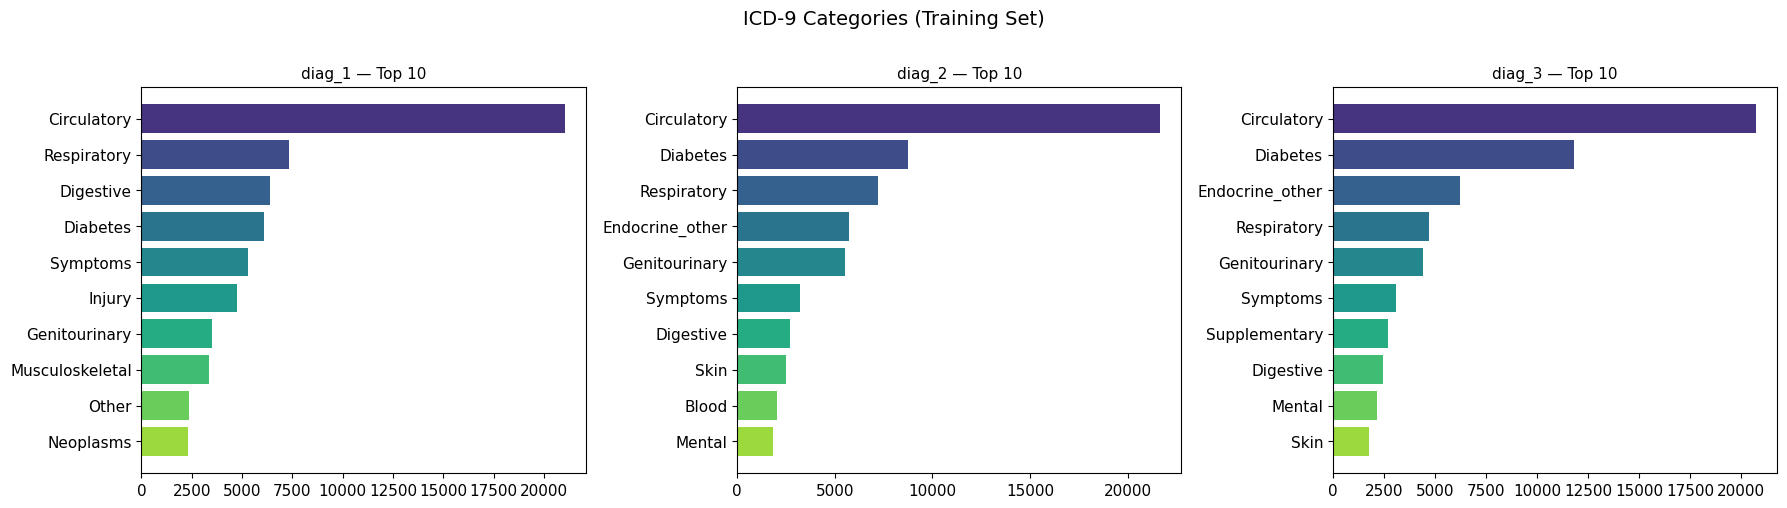

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(['diag_1','diag_2','diag_3']):
    cts = X_train[col].value_counts().head(10)
    colors = [plt.cm.viridis(x) for x in np.linspace(0.15, 0.85, len(cts))]
    axes[i].barh(cts.index.astype(str), cts.values, color=colors)
    axes[i].set_title(f'{col} — Top 10', fontsize=11); axes[i].invert_yaxis()
plt.suptitle('ICD-9 Categories (Training Set)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('Output/fig7_diagnosis_categories.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.2 Preprocessing Pipeline

Two preprocessing strategies for the two model families:

**SVM & Gradient Boosting:** `ColumnTransformer` inside `Pipeline` — imputation with missing indicators (Perez-Lebel et al., 2022), scaling for SVM, one-hot encoding for categoricals. All steps re-fitted on each CV fold to prevent data leakage.

**TabICL v2:** Receives raw `DataFrame` directly. The model handles imputation, encoding, outlier clipping, and normalisation internally — this is its designed usage mode (Qu et al., 2026). No `ColumnTransformer` needed.

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numerical_features = X_train.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical ({len(numerical_features)}): {numerical_features}")
print(f"Categorical ({len(categorical_features)}): {categorical_features}")

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent', add_indicator=True)),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

print("\nPreprocessor: Num(Imputer+indicator -> Scaler) | Cat(Imputer+indicator -> OHE)")

Numerical (8): ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
Categorical (38): ['race', 'gender', 'age', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'admission_type', 'discharge_disposition', 'admission_source']

Preprocessor: Num(Imputer+indicator -> Scaler) | Cat(Imputer+indicator -> OHE)


---
# Task 3: ML Pipeline (40%)

## 3.1 Metrics: Balanced Accuracy, AUC-ROC, F1-score

We report three complementary metrics. Balanced accuracy (average of per-class recall) accounts for any residual class imbalance after undersampling and is less susceptible to majority-class dominance than raw accuracy. AUC-ROC provides a threshold-independent measure of discriminative ability across all operating points. F1-score captures the trade-off between precision and recall, which is clinically meaningful: in readmission prediction, a false negative (missing a high-risk patient) is more consequential than a false positive (unnecessarily flagging a low-risk patient for follow-up).

- **Balanced Accuracy** (primary): average of per-class recall; robust to residual imbalance.
- **AUC-ROC**: threshold-independent discriminative ability across all operating points.
- **F1-score**: precision-recall trade-off; clinically meaningful for readmission prediction.


## 3.2 Models: Linear SVM (baseline) + Random Forest + Gradient Boosting

We selected three models representing complementary architectural families to enable meaningful comparison:
Linear SVM (baseline). As specified by the coursework, a linear SVM with soft-margin regularisation (hyperparameter C) serves as the discriminative linear baseline. It maximises the margin between classes in the feature space, is sensitive to feature scaling (which tests Pipeline correctness), and produces interpretable coefficients for Task 4. We tune C over a logarithmic grid: {0.001, 0.01, 0.1, 1, 10, 100}.


**TabICL v2 (Qu et al., 2026):** State-of-the-art tabular foundation model presented in this course by its authors. Uses in-context learning — a pretrained transformer processes train and test data in a single forward pass. Outperforms tuned XGBoost/CatBoost/LightGBM on ~80% of TabArena benchmarks *without hyperparameter tuning*. sklearn-compatible API (`fit`/`predict`/`predict_proba`). Inclusion provides a direct comparison between classical ML and the new foundation model paradigm.


Gradient Boosting. A sequential ensemble that iteratively fits weak learners to the residuals of previous iterations, primarily reducing bias. Unlike Random Forest (which averages many independent trees), Gradient Boosting builds each tree to correct the errors of the preceding ensemble, making it particularly effective for complex non-linear relationships in tabular data. The sklearn GradientBoostingClassifier is chosen over external libraries (XGBoost, LightGBM) because it integrates natively with the sklearn Pipeline and GridSearchCV infrastructure that underpins our nested cross-validation framework. We tune learning_rate ∈ {0.01, 0.1, 0.3}, n_estimators ∈ {100, 200, 500}, and max_depth ∈ {3, 5, 7}.

In [ ]:
from sklearn.model_selection import RepeatedStratifiedKFold, GridSearchCV, cross_validate
from sklearn.svm import LinearSVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score, f1_score,
                              ConfusionMatrixDisplay, RocCurveDisplay)
from tabicl import TabICLClassifier

# ── CV strategy ──
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)
print(f"CV: RepeatedStratifiedKFold(5 folds x 2 repeats = {rskf.get_n_splits()} evaluations per HP combo)")

# ── Model configurations ──
sklearn_models = {
    'Linear SVM': {
        'pipeline': make_pipeline(preprocessor,
                                  LinearSVC(dual='auto', max_iter=10000, random_state=42)),
        'param_grid': {
            'linearsvc__C': [0.001, 0.01, 0.1, 1, 10, 100]
        }
    },
    'Gradient Boosting': {
        'pipeline': make_pipeline(preprocessor,
                                  GradientBoostingClassifier(random_state=42)),
        'param_grid': {
            'gradientboostingclassifier__n_estimators': [100, 200],
            'gradientboostingclassifier__learning_rate': [0.01, 0.1, 0.3],
            'gradientboostingclassifier__max_depth': [3, 5, 7]
        }
    }
}

for name, cfg in sklearn_models.items():
    n_combos = 1
    for v in cfg['param_grid'].values():
        n_combos *= len(v)
    print(f"  {name}: {n_combos} HP combos x {rskf.get_n_splits()} folds = {n_combos * rskf.get_n_splits()} fits")
print(f"  TabICL v2: no tuning required (pretrained foundation model)")

CV: RepeatedStratifiedKFold(5 folds x 2 repeats = 10 evaluations per HP combo)
  Linear SVM: 6 HP combos x 10 folds = 60 fits
  Gradient Boosting: 18 HP combos x 10 folds = 180 fits
  TabICL v2: no tuning required (pretrained foundation model)


## 3.3 Nested Cross-Validation

We use `RepeatedStratifiedKFold(n_splits=5, n_repeats=2)` — 10 evaluations per HP combination. This strategy provides **low-variance performance estimates** by repeating the stratified split with different random seeds, which is the professor's preferred approach. Combined with the group-aware train/test split, this ensures both stable HP selection and uncontaminated final evaluation.

In [ ]:
# ── Train sklearn models with GridSearchCV + RSKF ──
gs_results = {}

for name, cfg in sklearn_models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    gs = GridSearchCV(
        estimator=cfg['pipeline'],
        param_grid=cfg['param_grid'],
        cv=rskf,
        scoring='balanced_accuracy',
        n_jobs=-1,
        refit=True,
        return_train_score=True,
        verbose=1
    )
    gs.fit(X_train, y_train)
    gs_results[name] = gs
    print(f"  Best params: {gs.best_params_}")
    print(f"  Best CV balanced accuracy: {gs.best_score_:.4f}")

print("\nAll sklearn models trained.")


Training Linear SVM...
Fitting 10 folds for each of 6 candidates, totalling 60 fits
  Best params: {'linearsvc__C': 0.1}
  Best CV balanced accuracy: 0.6340

Training Gradient Boosting...
Fitting 10 folds for each of 18 candidates, totalling 180 fits
  Best params: {'gradientboostingclassifier__learning_rate': 0.1, 'gradientboostingclassifier__max_depth': 7, 'gradientboostingclassifier__n_estimators': 200}
  Best CV balanced accuracy: 0.6442

All sklearn models trained.


In [ ]:
# ── Train and evaluate TabICL v2 (GPU, no HP tuning) ──
print("Training TabICL v2 on GPU...")
print("(No hyperparameter tuning — pretrained foundation model with default settings)")

tabicl_clf = TabICLClassifier(device='cuda', random_state=42)

# Cross-validate with the same RSKF for fair comparison
tabicl_cv = cross_validate(
    tabicl_clf, X_train, y_train,
    cv=rskf,
    scoring=['balanced_accuracy', 'f1', 'roc_auc'],
    return_train_score=True,
    n_jobs=1   # TabICL manages GPU parallelism internally
)

print(f"  CV Balanced Accuracy: {tabicl_cv['test_balanced_accuracy'].mean():.4f} "
      f"+/- {tabicl_cv['test_balanced_accuracy'].std():.4f}")
print(f"  CV F1:                {tabicl_cv['test_f1'].mean():.4f} "
      f"+/- {tabicl_cv['test_f1'].std():.4f}")
print(f"  CV AUC-ROC:           {tabicl_cv['test_roc_auc'].mean():.4f} "
      f"+/- {tabicl_cv['test_roc_auc'].std():.4f}")

# Fit final TabICL model on full training set for test evaluation
tabicl_final = TabICLClassifier(device='cuda', random_state=42)
tabicl_final.fit(X_train, y_train)
print("\nTabICL v2 trained on full training set.")

Training TabICL v2 on GPU...
(No hyperparameter tuning — pretrained foundation model with default settings)
INFO: You are downloading 'tabicl-classifier-v2-20260212.ckpt', the latest best-performing version, used in our TabICLv2 paper.

Checkpoint 'tabicl-classifier-v2-20260212.ckpt' not cached.



tabicl-classifier-v2-20260212.ckpt:   0%|          | 0.00/110M [00:00<?, ?B/s]

  CV Balanced Accuracy: 0.6455 +/- 0.0033
  CV F1:                0.6461 +/- 0.0058
  CV AUC-ROC:           0.7071 +/- 0.0036

TabICL v2 trained on full training set.


## 3.4 Hyperparameter performance

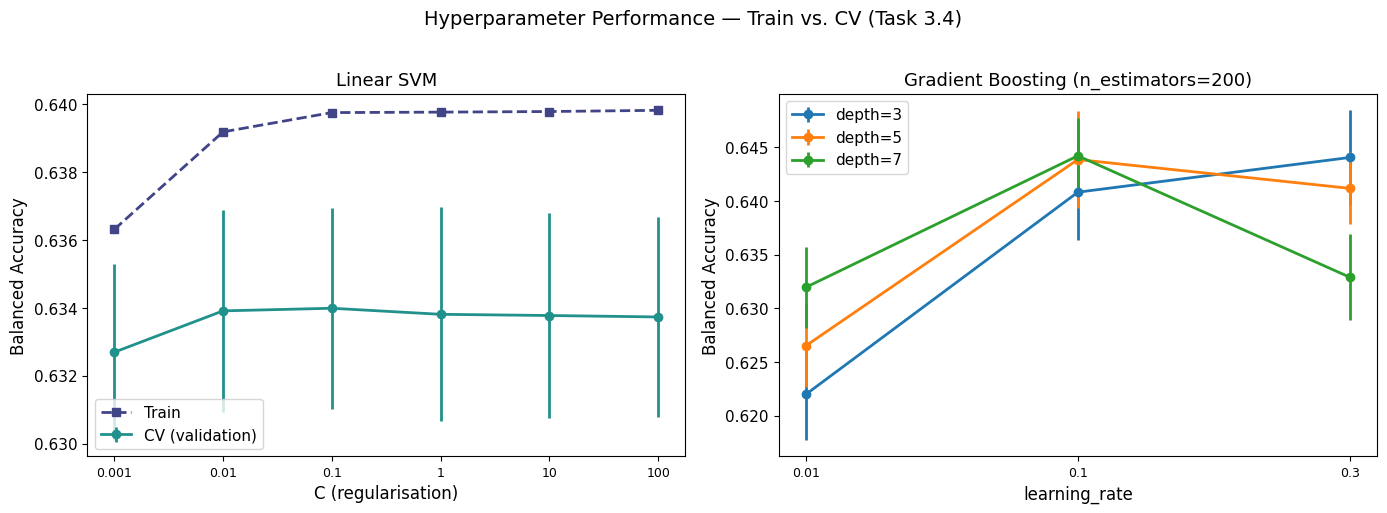

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── SVM: C vs balanced accuracy ──
gs_svm = gs_results['Linear SVM']
C_vals = sklearn_models['Linear SVM']['param_grid']['linearsvc__C']
axes[0].errorbar(range(len(C_vals)),
                 gs_svm.cv_results_['mean_test_score'],
                 yerr=gs_svm.cv_results_['std_test_score'],
                 label='CV (validation)', color=VIRIDIS_3[1], marker='o', lw=2)
axes[0].plot(range(len(C_vals)),
             gs_svm.cv_results_['mean_train_score'],
             label='Train', color=VIRIDIS_3[0], marker='s', lw=2, ls='--')
axes[0].set_xticks(range(len(C_vals)))
axes[0].set_xticklabels([str(c) for c in C_vals], fontsize=9)
axes[0].set_xlabel('C (regularisation)'); axes[0].set_ylabel('Balanced Accuracy')
axes[0].set_title('Linear SVM'); axes[0].legend()

# ── GB: learning_rate vs balanced accuracy, grouped by max_depth ──
gs_gb = gs_results['Gradient Boosting']
lr_vals = sklearn_models['Gradient Boosting']['param_grid']['gradientboostingclassifier__learning_rate']
for d in [3, 5, 7]:
    mask = np.array([p['gradientboostingclassifier__max_depth'] == d and
                     p['gradientboostingclassifier__n_estimators'] == 200
                     for p in gs_gb.cv_results_['params']])
    if mask.any():
        axes[1].errorbar(range(len(lr_vals)),
                         gs_gb.cv_results_['mean_test_score'][mask],
                         yerr=gs_gb.cv_results_['std_test_score'][mask],
                         label=f'depth={d}', marker='o', lw=2)
axes[1].set_xticks(range(len(lr_vals)))
axes[1].set_xticklabels([str(l) for l in lr_vals], fontsize=9)
axes[1].set_xlabel('learning_rate'); axes[1].set_ylabel('Balanced Accuracy')
axes[1].set_title('Gradient Boosting (n_estimators=200)'); axes[1].legend()

plt.suptitle('Hyperparameter Performance — Train vs. CV (Task 3.4)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('Output/fig8_hyperparameter_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.5 Results table

In [ ]:
# ── Evaluate all models on held-out test set ──
def evaluate_on_test(model, X_te, y_te):
    y_pred = model.predict(X_te)
    try:
        y_scores = model.decision_function(X_te)
    except AttributeError:
        try:
            y_scores = model.predict_proba(X_te)[:, 1]
        except AttributeError:
            y_scores = y_pred
    return {
        'bal_acc': balanced_accuracy_score(y_te, y_pred),
        'f1': f1_score(y_te, y_pred),
        'auc': roc_auc_score(y_te, y_scores)
    }

rows = []

# SVM and GB from GridSearchCV
for name, gs in gs_results.items():
    cv_mean = gs.cv_results_['mean_test_score'][gs.best_index_]
    cv_std  = gs.cv_results_['std_test_score'][gs.best_index_]
    test = evaluate_on_test(gs, X_test, y_test)
    rows.append({
        'Model': name,
        'CV Bal.Acc (mean +/- std)': f"{cv_mean:.3f} +/- {cv_std:.3f}",
        'Test Bal.Acc': f"{test['bal_acc']:.3f}",
        'Test F1': f"{test['f1']:.3f}",
        'Test AUC': f"{test['auc']:.3f}",
        'Best Params': str(gs.best_params_)
    })

# TabICL from cross_validate
tabicl_test = evaluate_on_test(tabicl_final, X_test, y_test)
rows.append({
    'Model': 'TabICL v2',
    'CV Bal.Acc (mean +/- std)': f"{tabicl_cv['test_balanced_accuracy'].mean():.3f} "
                                  f"+/- {tabicl_cv['test_balanced_accuracy'].std():.3f}",
    'Test Bal.Acc': f"{tabicl_test['bal_acc']:.3f}",
    'Test F1': f"{tabicl_test['f1']:.3f}",
    'Test AUC': f"{tabicl_test['auc']:.3f}",
    'Best Params': 'default (pretrained)'
})

results_df = pd.DataFrame(rows)
display(results_df)

,Model,CV Bal.Acc (mean +/- std),Test Bal.Acc,Test F1,Test AUC,Best Params
0,Linear SVM,0.634 +/- 0.003,0.632,0.627,0.689,{'linearsvc__C': 0.1}
1,Gradient Boosting,0.644 +/- 0.004,0.644,0.645,0.702,{'gradientboostingclassifier__learning_rate': ...
2,TabICL v2,0.646 +/- 0.003,0.645,0.648,0.705,default (pretrained)


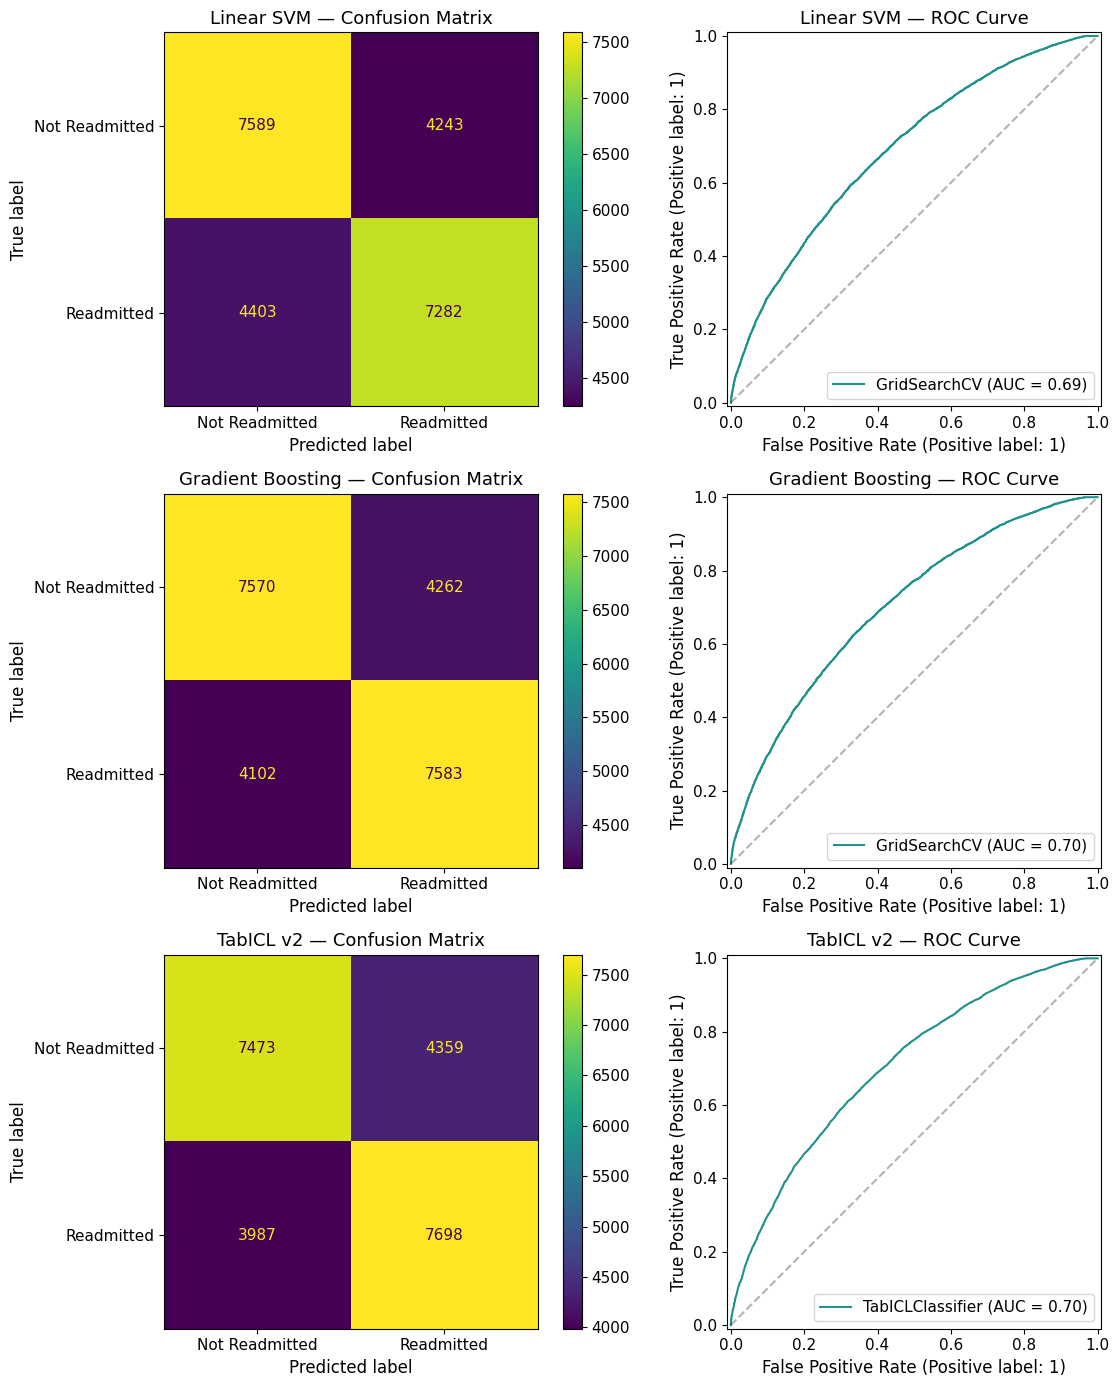

In [ ]:
# ── Confusion matrices and ROC curves ──
all_models = {
    'Linear SVM': gs_results['Linear SVM'],
    'Gradient Boosting': gs_results['Gradient Boosting'],
    'TabICL v2': tabicl_final
}

fig, axes = plt.subplots(3, 2, figsize=(12, 14))

for i, (name, model) in enumerate(all_models.items()):
    # Confusion matrix
    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test,
        display_labels=['Not Readmitted', 'Readmitted'],
        cmap='viridis', ax=axes[i][0]
    )
    axes[i][0].set_title(f'{name} — Confusion Matrix')

    # ROC curve
    try:
        RocCurveDisplay.from_estimator(model, X_test, y_test,
                                        ax=axes[i][1], color=VIRIDIS_3[1])
    except Exception:
        y_pred = model.predict(X_test)
        try:
            y_sc = model.predict_proba(X_test)[:,1]
            RocCurveDisplay.from_predictions(y_test, y_sc, ax=axes[i][1], color=VIRIDIS_3[1])
        except Exception:
            axes[i][1].text(0.5, 0.5, 'ROC unavailable', ha='center', va='center')
    axes[i][1].plot([0,1], [0,1], 'k--', alpha=0.3)
    axes[i][1].set_title(f'{name} — ROC Curve')

plt.tight_layout()
plt.savefig('Output/fig8b_confusion_roc.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.6 Results description

*[Report: Compare three generations of ML — linear (SVM), classical SOTA ensemble (GB), foundation model (TabICL v2). Discuss: CV-test gap for each model, whether TabICL's zero-tuning advantage translates to superior or comparable performance, std across RSKF folds as evidence of estimate stability, and implications for practical ML pipeline design in clinical settings.]*

---
# Task 4: Model Interpretation (10%)

## 4.1 Feature importance

In [ ]:
# ── Extract feature names from fitted preprocessor ──
best_svm = gs_results['Linear SVM'].best_estimator_
fitted_pre = best_svm[0]  # preprocessor

try:
    num_t = fitted_pre.named_transformers_['num']
    cat_t = fitted_pre.named_transformers_['cat']
    fnames = list(numerical_features)
    imp_n = num_t.named_steps['imputer']
    if hasattr(imp_n, 'indicator_') and imp_n.indicator_ is not None:
        fnames += [f"{numerical_features[i]}_missing" for i in imp_n.indicator_.features_]
    enc = cat_t.named_steps['encoder']
    imp_c = cat_t.named_steps['imputer']
    fnames += list(enc.get_feature_names_out(categorical_features))
    if hasattr(imp_c, 'indicator_') and imp_c.indicator_ is not None:
        fnames += [f"{categorical_features[i]}_missing" for i in imp_c.indicator_.features_]
    print(f"Feature names extracted: {len(fnames)}")
except Exception as e:
    Xt = fitted_pre.transform(X_train)
    fnames = [f"feat_{i}" for i in range(Xt.shape[1])]
    print(f"Fallback index-based names: {len(fnames)}")

Fallback index-based names: 302


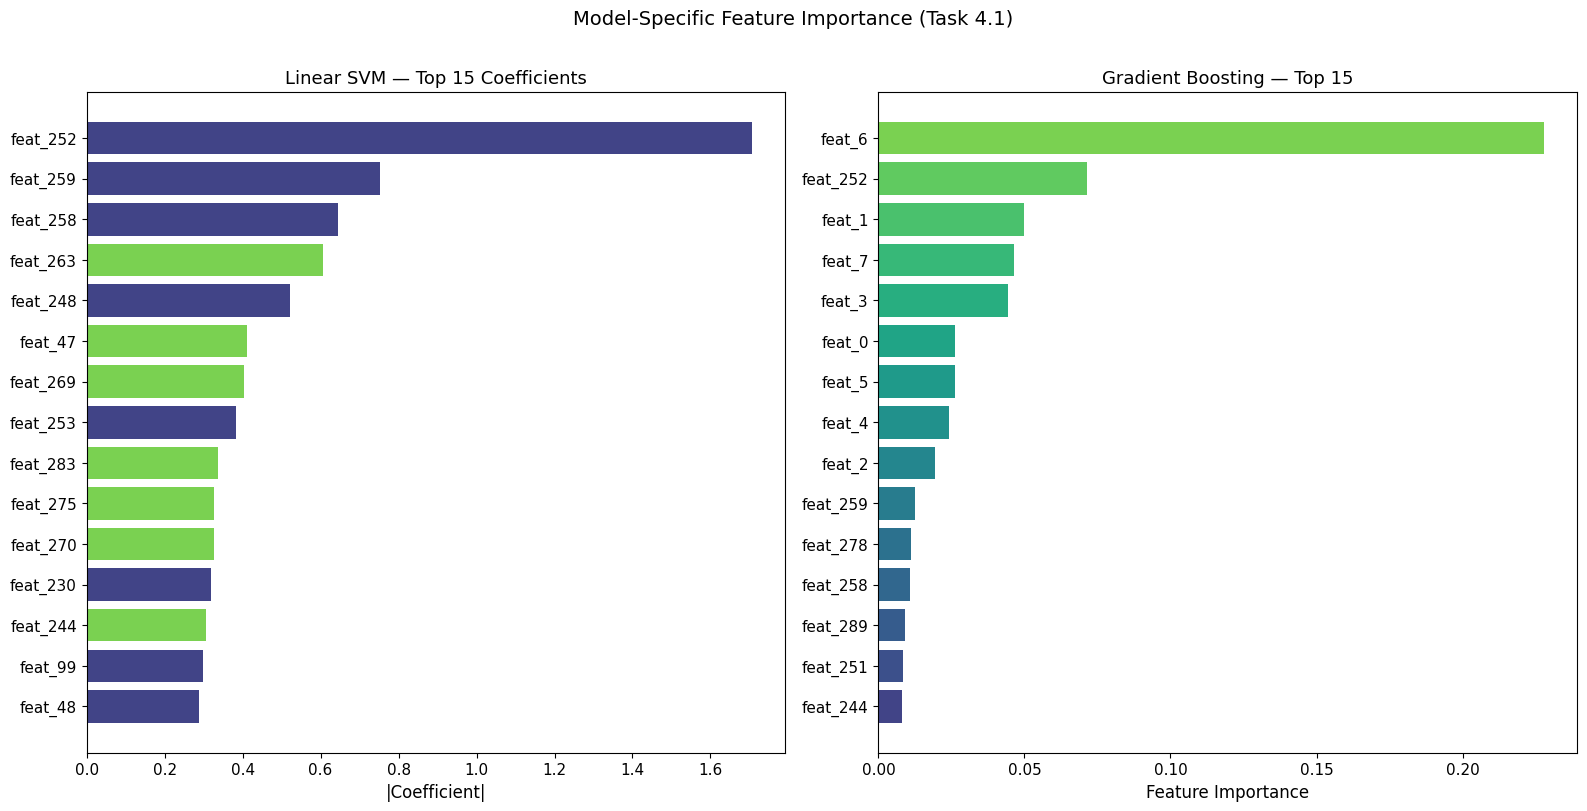

In [ ]:
top_n = 15
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# ── SVM coefficients ──
svm_coefs = best_svm[-1].coef_.ravel()
svm_df = pd.DataFrame({
    'f': fnames[:len(svm_coefs)], 'c': svm_coefs, 'a': np.abs(svm_coefs)
}).nlargest(top_n, 'a').iloc[::-1]
colors_s = [VIRIDIS_3[2] if v > 0 else VIRIDIS_3[0] for v in svm_df['c']]
axes[0].barh(svm_df['f'], svm_df['a'], color=colors_s)
axes[0].set_xlabel('|Coefficient|')
axes[0].set_title('Linear SVM — Top 15 Coefficients')

# ── GB feature importance ──
best_gb = gs_results['Gradient Boosting'].best_estimator_
gb_imp = best_gb[-1].feature_importances_
gb_df = pd.DataFrame({
    'f': fnames[:len(gb_imp)], 'i': gb_imp
}).nlargest(top_n, 'i').iloc[::-1]
axes[1].barh(gb_df['f'], gb_df['i'],
             color=[plt.cm.viridis(x) for x in np.linspace(0.2, 0.8, top_n)])
axes[1].set_xlabel('Feature Importance')
axes[1].set_title('Gradient Boosting — Top 15')

plt.suptitle('Model-Specific Feature Importance (Task 4.1)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('Output/fig9_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Permutation importance — model-agnostic, works for ALL 3 models ──
from sklearn.inspection import permutation_importance

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for i, (name, model) in enumerate(all_models.items()):
    pr = permutation_importance(
        model, X_test, y_test, n_repeats=10,
        random_state=42, n_jobs=1, scoring='balanced_accuracy'
    )
    n_feats = len(pr.importances_mean)
    # TabICL uses raw column names; sklearn models use preprocessed feature names
    if name == 'TabICL v2':
        names = X_test.columns.tolist()[:n_feats]
    else:
        names = fnames[:n_feats]

    pdf = pd.DataFrame({
        'f': names, 'i': pr.importances_mean, 's': pr.importances_std
    }).nlargest(top_n, 'i').iloc[::-1]

    axes[i].barh(pdf['f'], pdf['i'], xerr=pdf['s'],
                 color=[plt.cm.viridis(x) for x in np.linspace(0.2, 0.8, top_n)])
    axes[i].set_xlabel('Mean Accuracy Decrease')
    axes[i].set_title(f'{name}')

plt.suptitle('Permutation Feature Importance — All 3 Models (Task 4.1)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('figures/fig10_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## 4.2 & 4.3 Discussion

*[Report: Which features converge across all three models — including TabICL, which has a fundamentally different architecture? Does a pretrained transformer identify the same clinical signals as classical methods? Discuss clinical sense of top features (e.g., number_inpatient, number_diagnoses, time_in_hospital). Compare SVM coefficient-based interpretation vs. tree-based Gini importance vs. permutation importance (model-agnostic). If Gini and permutation disagree, consider correlated features splitting importance (L8, 01:00–01:20).]*

---
# Task 5: Alternative Pipeline with Feature Selection (25%)

## 5.1 Feature selection embedded in Pipeline

Feature selection MUST be inside the Pipeline to avoid data leakage. We apply `SelectKBest` to the best-performing sklearn model from Task 3.

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

# ── Identify best sklearn model ──
best_sklearn_name = max(gs_results, key=lambda x: gs_results[x].best_score_)
print(f"Best sklearn model: {best_sklearn_name} (CV Bal.Acc = {gs_results[best_sklearn_name].best_score_:.4f})")
print(f"TabICL v2 CV Bal.Acc: {tabicl_cv['test_balanced_accuracy'].mean():.4f}")

# ── Build pipeline with feature selection ──
best_cfg = sklearn_models[best_sklearn_name]
model_step = best_cfg['pipeline'].steps[-1]  # (name, estimator) tuple

pipeline_fs = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', SelectKBest(score_func=f_classif)),
    model_step
])

# HP grid: model HPs + k
param_grid_fs = dict(best_cfg['param_grid'])
param_grid_fs['selector__k'] = [10, 20, 30, 50, 'all']

print(f"\nPipeline: preprocessor -> SelectKBest -> {model_step[0]}")
print(f"k values: {param_grid_fs['selector__k']}")

In [ ]:
# ── GridSearchCV with feature selection ──
gs_fs = GridSearchCV(
    pipeline_fs, param_grid_fs, cv=rskf,
    scoring='balanced_accuracy', n_jobs=-1, refit=True, verbose=1
)
gs_fs.fit(X_train, y_train)

print(f"\nBest params: {gs_fs.best_params_}")
print(f"Best CV Bal.Acc: {gs_fs.best_score_:.4f}")
print(f"Selected k: {gs_fs.best_params_.get('selector__k', 'N/A')}")

## 5.2 Comparison table

In [ ]:
# ── With vs. without feature selection ──
test_fs = evaluate_on_test(gs_fs, X_test, y_test)
test_orig = evaluate_on_test(gs_results[best_sklearn_name], X_test, y_test)

comp = pd.DataFrame([
    {
        'Pipeline': f'{best_sklearn_name} (no selection)',
        'CV Bal.Acc': f"{gs_results[best_sklearn_name].best_score_:.4f}",
        'Test Bal.Acc': f"{test_orig['bal_acc']:.3f}",
        'Test F1': f"{test_orig['f1']:.3f}",
        'Test AUC': f"{test_orig['auc']:.3f}"
    },
    {
        'Pipeline': f'{best_sklearn_name} + SelectKBest(k={gs_fs.best_params_.get("selector__k","?")})',
        'CV Bal.Acc': f"{gs_fs.best_score_:.4f}",
        'Test Bal.Acc': f"{test_fs['bal_acc']:.3f}",
        'Test F1': f"{test_fs['f1']:.3f}",
        'Test AUC': f"{test_fs['auc']:.3f}"
    },
    {
        'Pipeline': 'TabICL v2 (no selection, no tuning)',
        'CV Bal.Acc': f"{tabicl_cv['test_balanced_accuracy'].mean():.4f}",
        'Test Bal.Acc': f"{tabicl_test['bal_acc']:.3f}",
        'Test F1': f"{tabicl_test['f1']:.3f}",
        'Test AUC': f"{tabicl_test['auc']:.3f}"
    }
])
display(comp)

## 5.3 Discussion

*[Report: Did feature selection improve accuracy? Following L9 (00:21): "There are very few occasions when feature selection improves accuracy." Regularised models and ensembles already handle irrelevant features internally. If k='all' was selected as optimal, this confirms the professor's point. Discuss the interpretability value of feature selection even without accuracy gains. Compare against TabICL v2, which required neither feature selection nor HP tuning — what does this imply for the future of tabular ML pipeline design?]*

In [ ]:
import os
os.chdir('/content/drive/MyDrive/Applied Artificial Intelligence/Code')

In [ ]:
%%capture
!apt-get update --quiet
!apt-get install -y texlive-xetex texlive-fonts-recommended texlive-plain-generic pandoc --quiet

In [ ]:
!jupyter nbconvert --to pdf "COMP0189_Coursework1_v0.2.ipynb"

[NbConvertApp] Converting notebook COMP0189_Coursework1_v0.2.ipynb to pdf
[NbConvertApp] Support files will be in COMP0189_Coursework1_v0.2_files/
[NbConvertApp] Making directory ./COMP0189_Coursework1_v0.2_files
[NbConvertApp] Writing 179277 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 810910 bytes to COMP0189_Coursework1_v0.2.pdf
